# BME-336546-C06-Nonlinear classification (SVM and Random forest)


## Data loading

In [1]:

import numpy as np
import pickle
import sys
import pandas as pd
import matplotlib as mpl
import seaborn as sns
import matplotlib.pyplot as plt
mpl.style.use(['ggplot']) 
%matplotlib inline
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss
from sklearn.pipeline import Pipeline

In this tutorial we would use data that you can find within `sklearn.datasets`. The chosen data are concentric circles.

In [4]:
from sklearn.datasets import make_circles
X, y = make_circles(1000, factor=.1, noise=.2, random_state=336546)

As usual, we should split our data into training and testing sets:

In [5]:
X_train, x_test, Y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state = 10, stratify=y)

In [6]:
def plot_radar(clf, clf_type):
    labels=np.array(['Accuracy', 'F1', 'PPV', 'Sensitivity', 'AUROC']) 
    score_mat_train = np.stack((clf.cv_results_['mean_train_accuracy'], clf.cv_results_['mean_train_f1'],
                               clf.cv_results_['mean_train_precision'], clf.cv_results_['mean_train_recall'],
                               clf.cv_results_['mean_train_roc_auc']), axis=0)
    score_mat_val = np.stack((clf.cv_results_['mean_test_accuracy'], clf.cv_results_['mean_test_f1'],
                               clf.cv_results_['mean_test_precision'], clf.cv_results_['mean_test_recall'],
                               clf.cv_results_['mean_test_roc_auc']), axis=0)


    angles=np.linspace(0, 2*np.pi, len(labels), endpoint=False)

    angles=np.concatenate((angles,[angles[0]]))
    cv_dict = clf.cv_results_['params']
    fig=plt.figure(figsize=(18,14))
    if 'svm__gamma' in cv_dict[0]:
        new_list = [(i, item) for i, item in enumerate(cv_dict) if
                    item["svm__kernel"] == clf_type[0] and item["svm__gamma"] == clf_type[1]]
    else:
        new_list = [(i, item) for i, item in enumerate(cv_dict) if
                    item["svm__kernel"] == clf_type[0]]
    for idx, val in enumerate(new_list):
        ax = fig.add_subplot(1, len(new_list), 1+idx, polar=True)
        rel_idx, rel_dict = val
        stats_train = score_mat_train[:, rel_idx]
        stats_train=np.concatenate((stats_train,[stats_train[0]]))
        ax.plot(angles, stats_train, 'o-', linewidth=2)
        ax.fill(angles, stats_train, alpha=0.25)
        stats_val = score_mat_val[:, rel_idx]
        stats_val=np.concatenate((stats_val,[stats_val[0]]))
        ax.plot(angles, stats_val, 'o-', linewidth=2)
        ax.fill(angles, stats_val, alpha=0.25)
        ax.set_thetagrids(angles[:-1] * 180/np.pi, labels)
        if idx == 0:
            ax.set_ylabel(clf_type[0], fontsize=18)
        ax.set_title('C = %.3f' % (rel_dict['svm__C']))
        if 'svm__gamma' in cv_dict[0]:
            ax.set_xlabel('$\gamma = %s $' % (rel_dict['svm__gamma']))
        ax.set_ylim([0,1])
        ax.legend(['Train','Validation'])
        ax.grid(True)
        
    plt.show()

In [7]:
def plot_dataset(x_train, x_test, y_train, y_test, axes_range):
    fig, axs = plt.subplots(1, 2, figsize=(12,6))
    for idx, ax in enumerate(axs.flatten()):
        if idx == 0:
            ax.plot(x_train[:, 0][y_train==0], x_train[:, 1][y_train==0], "bs")
            ax.plot(x_train[:, 0][y_train==1], x_train[:, 1][y_train==1], "g^")
            ax.set_title('Train')
        else:
            ax.plot(x_test[:, 0][y_test==0], x_test[:, 1][y_test==0], "bs")
            ax.plot(x_test[:, 0][y_test==1], x_test[:, 1][y_test==1], "g^")
            ax.set_title('Test')
        ax.axis(axes_range)
        ax.grid(True, which='both')
        ax.set_xlabel(r"$x_1$", fontsize=20)
        ax.set_ylabel(r"$x_2$", fontsize=20, rotation=0)
    return fig, axs

In [8]:
def plot_predictions(clf, axs, axes_range):
    x0s = np.linspace(axes_range[0], axes_range[1], 100)
    x1s = np.linspace(axes_range[2], axes_range[3], 100)
    x0, x1 = np.meshgrid(x0s, x1s)
    X = np.c_[x0.ravel(), x1.ravel()]
    y_pred = clf.predict(X).reshape(x0.shape)
    y_decision = clf.decision_function(X).reshape(x0.shape)
    for idx, ax in enumerate(axs.flatten()):
        ax.contourf(x0, x1, y_pred, cmap=plt.cm.brg, alpha=0.2)
        ax.contourf(x0, x1, y_decision, cmap=plt.cm.brg, alpha=0.1)
        if idx == 0:
            ax.set_title('Train')
        else:
            ax.set_title('Test')

Let's look at our data sets:

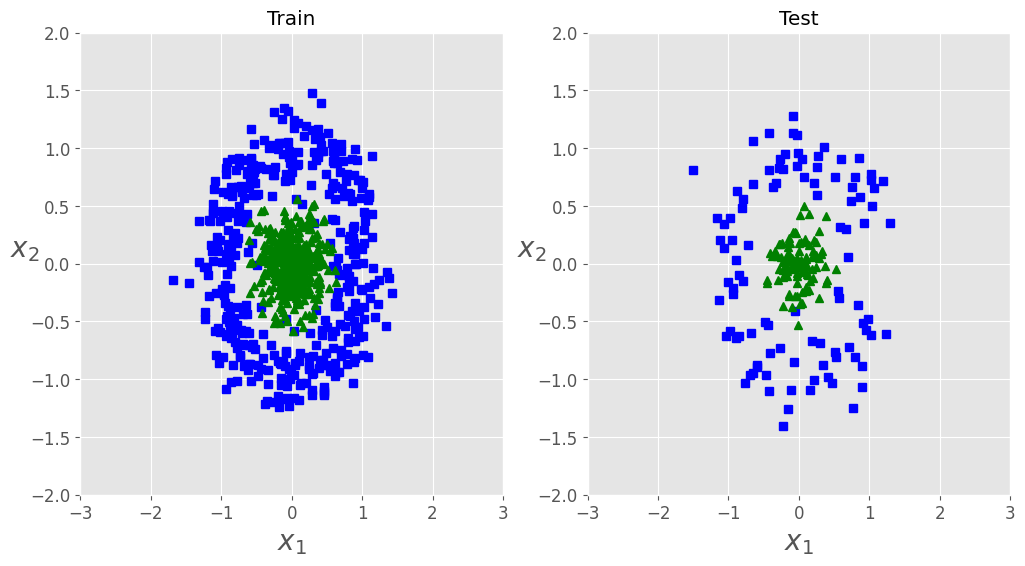

In [9]:
axes_range = [-3, 3, -2, 2]
_, _ = plot_dataset(X_train, x_test, Y_train, y_test, axes_range)

This data set is clearly non-linearly separable, at least not at this domain. We should now use the `StratifiedKFold` class as in the previous tutorial with 3 splits and then we will use `GridSearchCV` to look for the best linear SVM among the different given C values for classification penalties. Use `Pipeline` to insert scaling and notice that the kernel should not be a string but rather a one-element list containing the adequate string for linear kernel.\
Again, we would look for the best estimator according to AUROC performance and for "running info" we would use `verbose=3`. Name the `GridSearchCV` as `svm_lin` and use `svm` string for the dictionary of `Pipeline`.

In [10]:
n_splits = 3
skf = StratifiedKFold(n_splits=n_splits, random_state=10, shuffle=True)

In [14]:
#C1
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
svc = SVC(probability=True, random_state=336546)
C = np.array([0.001, 0.01, 1, 10, 100, 1000])
#--------------------------Impelment your code here:-------------------------------------
pipe = Pipeline(steps=[('scale', StandardScaler()), ('svm', svc)])
param_grid = {'svm__C': C, 'svm__kernel': ['linear']}
scoring = {'accuracy': 'accuracy', 'f1': 'f1', 'precision': 'precision', 'recall': 'recall', 'roc_auc': 'roc_auc'}
svm_lin = GridSearchCV(pipe, param_grid, cv=skf, scoring=scoring, refit='roc_auc', verbose=3, n_jobs=-1)
svm_lin.fit(X_train, Y_train)
#------------------------------------------------------------------------------------------

Fitting 3 folds for each of 6 candidates, totalling 18 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...ate=336546))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'svm__C': array([1.e-03...e+02, 1.e+03]), 'svm__kernel': ['linear']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","{'accuracy': 'accuracy', 'f1': 'f1', 'precision': 'precision', 'recall': 'recall', ...}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'roc_auc'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more

Choose the best linear model and name it as `best_svm_lin`. In addition, print the parameters adequate to the best classifier

In [15]:
#C2
#--------------------------Impelment your code here:-------------------------------------
best_svm_lin = svm_lin.best_estimator_
print("Best parameters:", svm_lin.best_params_)
print("Best AUROC:", svm_lin.best_score_)
#-----------------------------------------------------------------------------------------

Best parameters: {'svm__C': np.float64(1.0), 'svm__kernel': 'linear'}
Best AUROC: 0.4681173250711787


### Expected outpout:
<center><img src="outputs/1.PNG" width="380"><center>

Now let's look at the performances as a function of missclassification penalties:

In [16]:
clf_type = ['linear']
plot_radar(svm_lin, clf_type)

KeyError: 'mean_train_accuracy'

### Expected outpout:
<center><img src="outputs/2.PNG" width="880"><center>

And now, we would like to visualize the classification of our chosen estimator using `decision_function` method (used within `plot_predictions`).

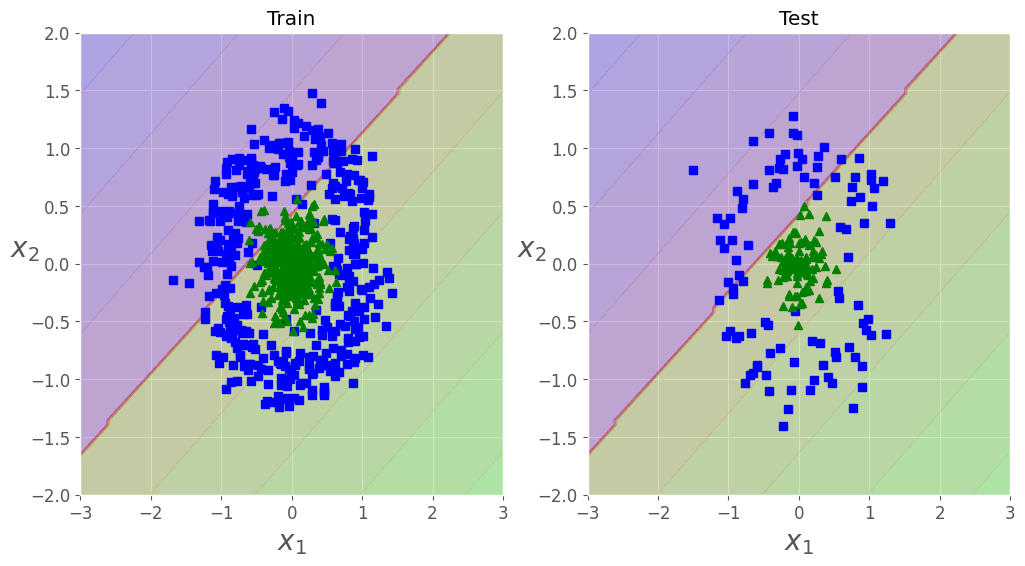

In [17]:
axes_range = [-3, 3, -2, 2]
_, axs = plot_dataset(X_train, x_test, Y_train, y_test, axes_range)
plot_predictions(best_svm_lin, axs, axes_range)

### Expected outpout:
<center><img src="outputs/3.PNG" width="380"><center>

In [20]:
from sklearn.metrics import confusion_matrix
calc_TN = lambda y_true, y_pred: confusion_matrix(y_true, y_pred)[0, 0]
calc_FP = lambda y_true, y_pred: confusion_matrix(y_true, y_pred)[0, 1]
calc_FN = lambda y_true, y_pred: confusion_matrix(y_true, y_pred)[1, 0]
calc_TP = lambda y_true, y_pred: confusion_matrix(y_true, y_pred)[1, 1]

Calculate the statistics and plot the confusion matrix as in previous tutorial.

Accuracy: 0.685
Precision: 0.615
Recall: 0.990
F1 Score: 0.759


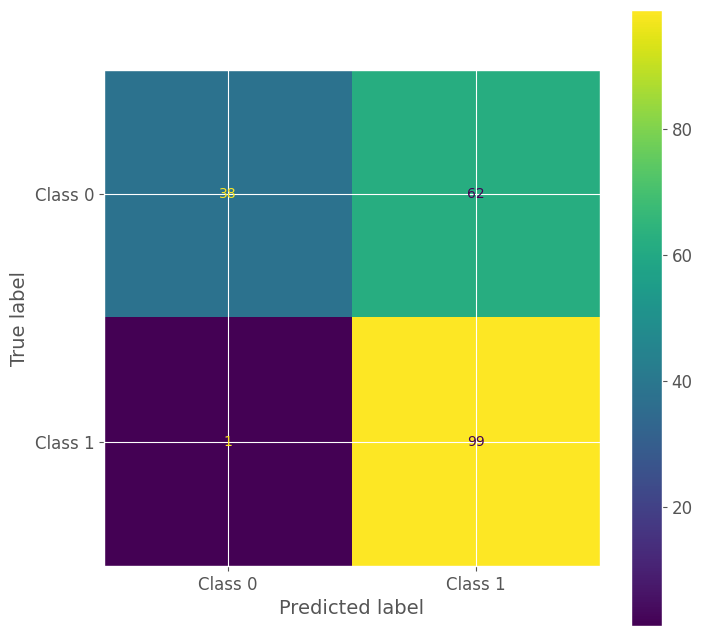

AUROC is 0.509


In [21]:
#C3
from sklearn.metrics import roc_auc_score, ConfusionMatrixDisplay

y_pred_test = best_svm_lin.predict(x_test) #NOTICE NOT TO USE THE STANDARDIZED DATA.
y_pred_proba_test = best_svm_lin.predict_proba(x_test)
#--------------------------Impelment your code here:-------------------------------------
TN = calc_TN(y_test, y_pred_test)
FP = calc_FP(y_test, y_pred_test)
FN = calc_FN(y_test, y_pred_test)
TP = calc_TP(y_test, y_pred_test)
accuracy = (TP + TN) / (TP + TN + FP + FN)
precision = TP / (TP + FP)
recall = TP / (TP + FN)
f1 = 2 * (precision * recall) / (precision + recall)

print(f'Accuracy: {accuracy:.3f}')
print(f'Precision: {precision:.3f}')
print(f'Recall: {recall:.3f}')
print(f'F1 Score: {f1:.3f}')

cm = confusion_matrix(y_test, y_pred_test)
fig, ax = plt.subplots(figsize=(8, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Class 0', 'Class 1'])
disp.plot(ax=ax)
plt.show()
#------------------------------------------------------------------------------------------
print('AUROC is {:.3f}'.format(roc_auc_score(y_test, y_pred_proba_test[:,1])))

### Expected outpout:
<center><img src="outputs/4.PNG" width="380"><center>

Now we would look for a **nonlinear** SVM calssifier. Use the kernels `rbf` and `poly`. For $\gamma$, use `auto` and `scale`. The order of the polynom should be 3 (so it won't take more than several minutes). Notice to use a single-element list for this.

In [22]:
#C4
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
svc = SVC(probability=True)
C = np.array([1, 100, 1000])#, 10, 100, 1000])
#--------------------------Impelment your code here:-------------------------------------
pipe = Pipeline(steps=[('scale', StandardScaler()), ('svm', svc)])
param_grid = {'svm__C': C, 'svm__kernel': ['rbf', 'poly'], 'svm__gamma': ['auto', 'scale'], 'svm__degree': [3]}
scoring = {'accuracy': 'accuracy', 'f1': 'f1', 'precision': 'precision', 'recall': 'recall', 'roc_auc': 'roc_auc'}
svm_nonlin = GridSearchCV(pipe, param_grid, cv=skf, scoring=scoring, refit='roc_auc', verbose=3, n_jobs=-1)
svm_nonlin.fit(X_train, Y_train)
#-----------------------------------------------------------------------------------------

Fitting 3 folds for each of 12 candidates, totalling 36 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...ility=True))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'svm__C': array([ 1, 100, 1000]), 'svm__degree': [3], 'svm__gamma': ['auto', 'scale'], 'svm__kernel': ['rbf', 'poly']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","{'accuracy': 'accuracy', 'f1': 'f1', 'precision': 'precision', 'recall': 'recall', ...}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'roc_auc'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbos

Choose the best estimator and name it as `best_svm_nonlin`.

---
<span style="color:red">***Question:***</span> *Which kernel do you think is more proper to use?*

---

In [23]:
#C5
#--------------------------Impelment your code here:-------------------------------------
best_svm_nonlin = svm_nonlin.best_estimator_
print("Best parameters:", svm_nonlin.best_params_)
print("Best AUROC:", svm_nonlin.best_score_)
#------------------------------------------------------------------------------------------

Best parameters: {'svm__C': np.int64(1), 'svm__degree': 3, 'svm__gamma': 'auto', 'svm__kernel': 'rbf'}
Best AUROC: 0.9974310144118009


### Expected outpout:
<center><img src="outputs/5.PNG" width="380"><center>

Now you can plot The performances as a function of missclassification penalties for different kernels and $\gamma$.

In [ ]:
clf_type = ['rbf', 'scale']
plot_radar(svm_nonlin, clf_type)
clf_type = ['poly', 'scale']
plot_radar(svm_nonlin, clf_type)

### Expected outpout:
<center><img src="outputs/6.PNG" width="700"><center>

Let's visualize the decision function upon our data:

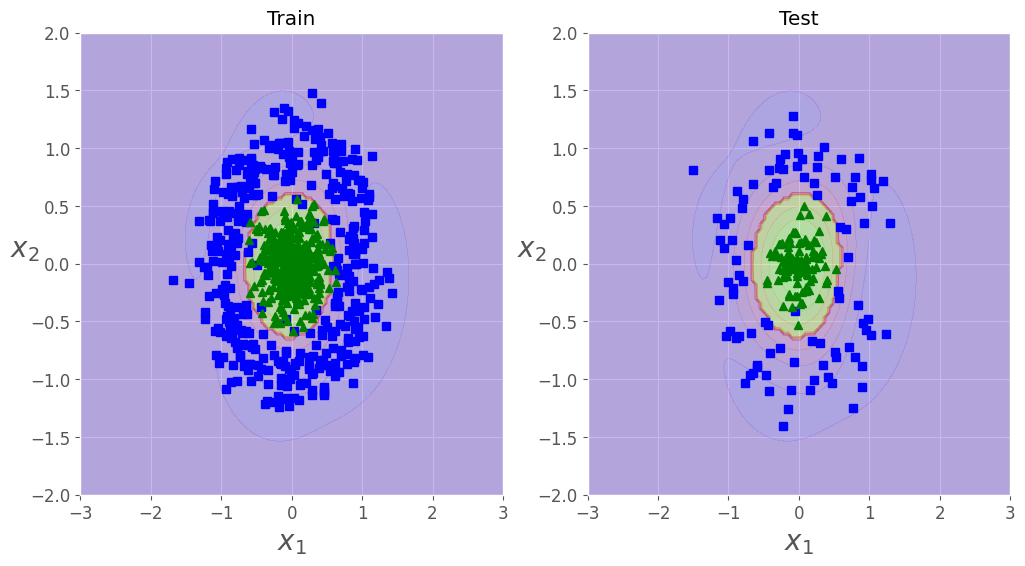

In [24]:
_, axs = plot_dataset(X_train, x_test, Y_train, y_test, axes_range)
plot_predictions(best_svm_nonlin, axs, axes_range)

### Expected outpout:
<center><img src="outputs/7.PNG" width="380"><center>

Calculate the statistics and plot the confusion matrix as in previous tutorial.

Accuracy: 0.995
Precision: 0.990
Recall: 1.000
F1 Score: 0.995


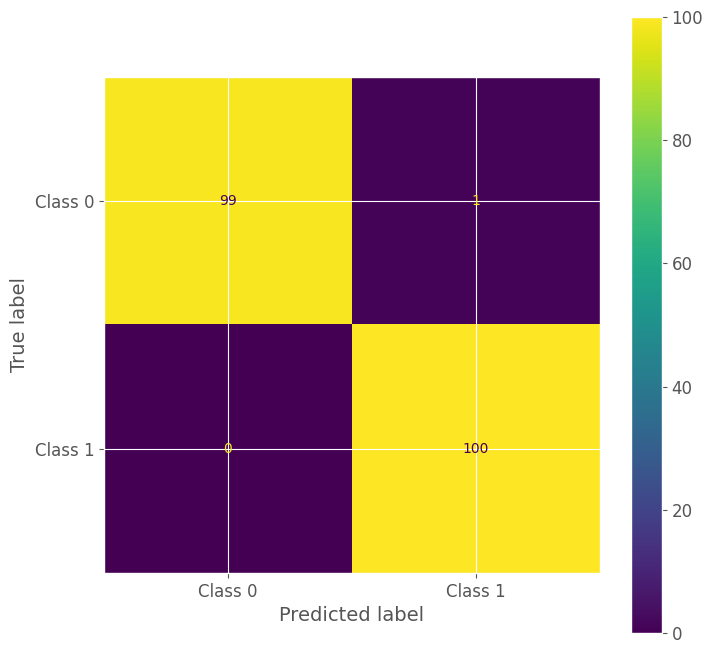

AUROC is 0.998


In [25]:
#C6
from sklearn.metrics import roc_auc_score, ConfusionMatrixDisplay

y_pred_test = best_svm_nonlin.predict(x_test) #NOTICE NOT TO USE THE STANDARDIZED DATA.
y_pred_proba_test = best_svm_nonlin.predict_proba(x_test)
#--------------------------Impelment your code here:-------------------------------------
TN = calc_TN(y_test, y_pred_test)
FP = calc_FP(y_test, y_pred_test)
FN = calc_FN(y_test, y_pred_test)
TP = calc_TP(y_test, y_pred_test)
accuracy = (TP + TN) / (TP + TN + FP + FN)
precision = TP / (TP + FP)
recall = TP / (TP + FN)
f1 = 2 * (precision * recall) / (precision + recall)

print(f'Accuracy: {accuracy:.3f}')
print(f'Precision: {precision:.3f}')
print(f'Recall: {recall:.3f}')
print(f'F1 Score: {f1:.3f}')

cm = confusion_matrix(y_test, y_pred_test)
fig, ax = plt.subplots(figsize=(8, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Class 0', 'Class 1'])
disp.plot(ax=ax)
plt.show()
#------------------------------------------------------------------------------------------
print('AUROC is {:.3f}'.format(roc_auc_score(y_test, y_pred_proba_test[:,1])))

### Expected outpout:
<center><img src="outputs/8.PNG" width="400"><center>

Here, we will only introduce a powerful classifier named *random forest* that was also used in the last part of *HW1*. Calculate the statistics and plot the confusion matrix as in previous tutorial.

Accuracy: 0.990
Precision: 0.980
Recall: 1.000
F1 Score: 0.990


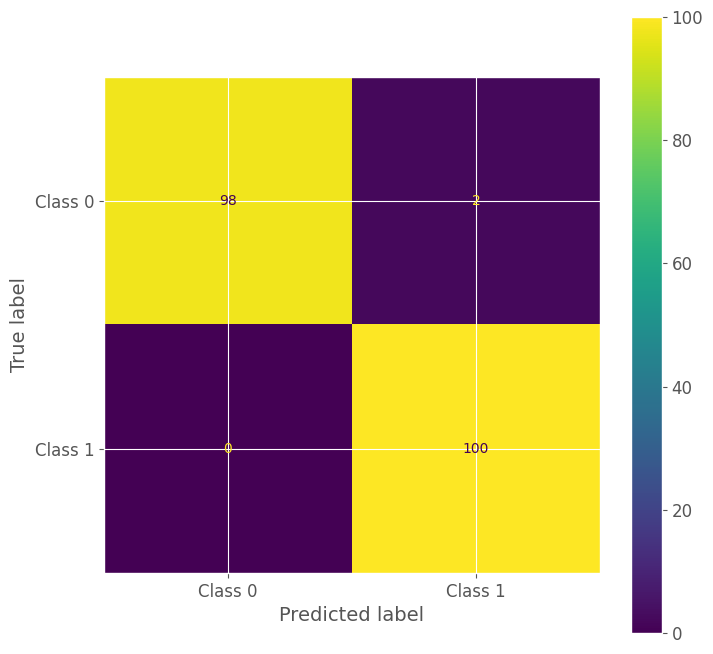

AUROC is 1.000


In [27]:
#C7
from sklearn.metrics import roc_auc_score, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
rfc = Pipeline(steps=[('scale', StandardScaler()), ('rfc', RandomForestClassifier(max_depth=4, random_state=336546, criterion='gini'))])
rfc.fit(X_train, Y_train)
y_pred_test = rfc.predict(x_test) #NOTICE NOT TO USE THE STANDARDIZED DATA.
y_pred_proba_test = rfc.predict_proba(x_test)
#--------------------------Impelment your code here:-------------------------------------
TN = calc_TN(y_test, y_pred_test)
FP = calc_FP(y_test, y_pred_test)
FN = calc_FN(y_test, y_pred_test)
TP = calc_TP(y_test, y_pred_test)
accuracy = (TP + TN) / (TP + TN + FP + FN)
precision = TP / (TP + FP)
recall = TP / (TP + FN)
f1 = 2 * (precision * recall) / (precision + recall)

print(f'Accuracy: {accuracy:.3f}')
print(f'Precision: {precision:.3f}')
print(f'Recall: {recall:.3f}')
print(f'F1 Score: {f1:.3f}')

cm = confusion_matrix(y_test, y_pred_test)
fig, ax = plt.subplots(figsize=(8, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Class 0', 'Class 1'])
disp.plot(ax=ax)
plt.show()
#------------------------------------------------------------------------------------------
print('AUROC is {:.3f}'.format(roc_auc_score(y_test, y_pred_proba_test[:,1])))

### Expected outpout:
<center><img src="outputs/9.PNG" width="380"><center>

Finally, we will compare the classifiers according to AUROC.

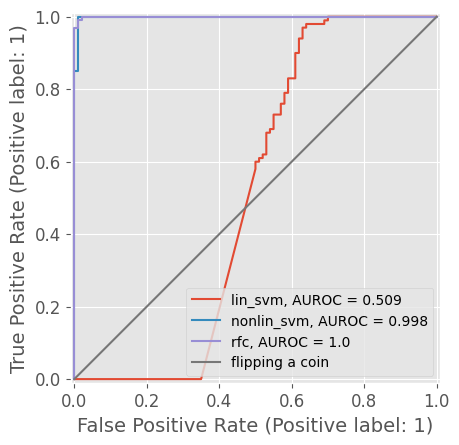

In [29]:
classifiers = [best_svm_lin, best_svm_nonlin, rfc]
roc_score = []
plt.figure()
ax = plt.gca()
from sklearn.metrics import RocCurveDisplay
for clf in classifiers:
    RocCurveDisplay.from_estimator(clf, x_test, y_test, ax=ax)
    roc_score.append(np.round(roc_auc_score(y_test, clf.predict_proba(x_test)[:,1]), decimals=3))
ax.plot(np.linspace(0,1,x_test.shape[0]),np.linspace(0,1,x_test.shape[0]))
plt.legend(('lin_svm, AUROC = '+str(roc_score[0]),'nonlin_svm, AUROC = '+str(roc_score[1]),'rfc, AUROC = '+str(roc_score[2]),'flipping a coin'))

### Expected outpout:
<center><img src="outputs/10.PNG" width="380"><center>

#### *This tutorial was written by [Moran Davoodi](mailto:morandavoodi@gmail.com) & Alon Begin with the assitance of [Yuval Ben Sason](mailto:yuvalbse@gmail.com) & Kevin Kotzen*